# 分类算法与模型（上）：从真实邮件到概率、邻居与证据

**课堂实践 · 约 40 分钟**

这份 Notebook 使用 UCI Machine Learning Repository 的 **Spambase**。每一行是一封真实邮件的特征记录，标签 `1` 表示垃圾邮件，`0` 表示正常邮件。数据源共有 **4,601 封邮件、57 项输入特征**。我们依次学习逻辑回归、K 近邻和朴素贝叶斯，并用同一批独立测试邮件比较预测。

**数据说明。** 数据提供的是 48 个单词频率百分比、6 个字符频率百分比及 3 个连续大写字母长度统计；**没有邮件原文，也没有真实词次数**。体育文本的多项式朴素贝叶斯示例直接取自课件，与真实邮件实验分开。Spambase 来自 1999 年的特定邮件来源，测试结果不等同于现代邮箱的效果。

**来源与许可：** Hopkins, Reeber, Forman & Suermondt (1999), *Spambase*, UCI, DOI: [10.24432/C53G6X](https://doi.org/10.24432/C53G6X)，[数据页面](https://archive.ics.uci.edu/dataset/94/spambase)。数据按 [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) 提供。Notebook 内附原始数据的压缩副本，可在 Kaggle 关闭 Internet 的情况下直接 `Run All`；如添加 `spambase.data` 为 Input，则优先读取该文件。


## 1. 任务、特征与训练范围

输入 `X` 是邮件已经观察到的特征，目标 `y` 是已标注的类别。先划分训练集、验证集和测试集；之后的标准化只在训练数据内拟合。测试集留到所有模型和阈值确定之后。


In [3]:
from pathlib import Path
import io
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    display = print

words = 'make address all 3d our over remove internet order mail receive will people report addresses free business email you credit your font 000 money hp hpl george 650 lab labs telnet 857 data 415 85 technology 1999 parts pm direct cs meeting original project re edu table conference'.split()
chars = [';', '(', '[', '!', '$', '#']
feature_names = ([f'word_freq_{w}' for w in words] + [f'char_freq_{c}' for c in chars]
                 + ['capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total'])
assert len(feature_names) == 57

# 定位 spambase.zip：优先当前目录，其次 Kaggle 的 /kaggle/input
zip_candidates = [Path('spambase.zip')] + (list(Path('/kaggle/input').glob('**/spambase.zip')) if Path('/kaggle/input').exists() else [])
zip_path = next((p for p in zip_candidates if p.is_file()), None)
if zip_path is None:
    raise FileNotFoundError('未找到 spambase.zip，请把压缩包放到 Notebook 同目录或 /kaggle/input 下')

with zipfile.ZipFile(zip_path) as zf:
    raw_data = zf.read('spambase.data')

df = pd.read_csv(io.BytesIO(raw_data), header=None, names=feature_names + ['spam'])
print('来源：', zip_path)
print('形状：', df.shape, '；垃圾邮件数：', df.spam.sum())
display(df[['word_freq_free', 'char_freq_!', 'capital_run_length_total', 'spam']].head())


来源： spambase.zip
形状： (4601, 58) ；垃圾邮件数： 1813


,word_freq_free,char_freq_!,capital_run_length_total,spam
0,0.32,0.778,278,1
1,0.14,0.372,1028,1
2,0.06,0.276,2259,1
3,0.31,0.137,191,1
4,0.31,0.135,191,1


`word_freq_free=0.64` 的意思是邮件中匹配 `free` 的词约占全部词的 0.64%，不是出现了 0.64 次。`capital_run_length_total` 是连续大写字母片段长度的总和，与词频百分比单位不同。下图先观察原始数据的标签和一个特征。


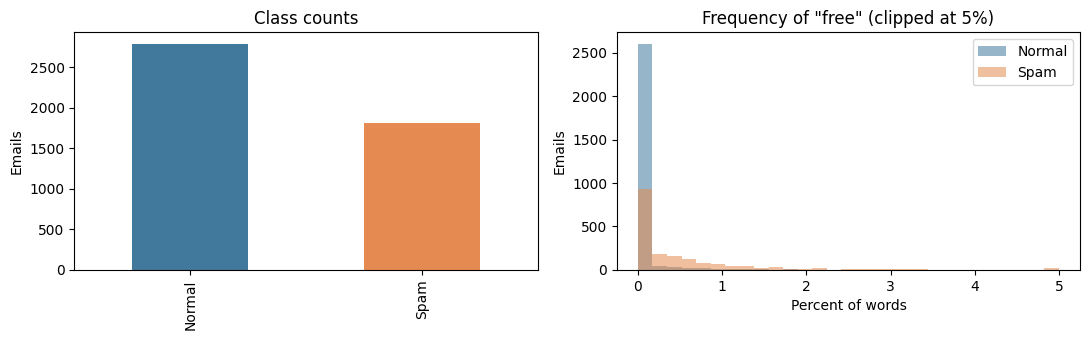

垃圾邮件占比：39.4%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df.spam.map({0:'Normal',1:'Spam'}).value_counts().reindex(['Normal','Spam']).plot.bar(ax=ax[0], color=['#41799c','#e58b51'])
ax[0].set(title='Class counts', xlabel='', ylabel='Emails')
for class_id, label, color in [(0,'Normal','#41799c'),(1,'Spam','#e58b51')]:
    vals = df.loc[df.spam==class_id, 'word_freq_free'].clip(upper=5)
    ax[1].hist(vals, bins=np.linspace(0,5,30), alpha=.55, label=label, color=color)
ax[1].set(title='Frequency of "free" (clipped at 5%)', xlabel='Percent of words', ylabel='Emails')
ax[1].legend(); plt.tight_layout(); plt.show()
print('垃圾邮件占比：{:.1%}'.format(df.spam.mean()))


原始档案有重复的特征记录；还有极少数**同一组特征却标了不同类别**的记录。为了避免相同输入跨训练集与测试集造成数据泄漏，先剔除无法从现有特征分辨标签的冲突组，再对其余特征完全相同的记录只保留一条。保留原始行号便于回查；此处理会改变用于建模的样本数。


In [5]:
conflict_mask = df.groupby(feature_names, sort=False)['spam'].transform('nunique').gt(1)
clean = df.loc[~conflict_mask].drop_duplicates(subset=feature_names).copy()
print('原始邮件记录：',len(df))
print('冲突标签记录：',int(conflict_mask.sum()),'；去重后用于建模：',len(clean))
assert not clean.duplicated(subset=feature_names).any()


原始邮件记录： 4601
冲突标签记录： 6 ；去重后用于建模： 4204


In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X, y = clean.drop(columns='spam'), clean['spam']
X_work, X_test, y_work, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_work, y_work, test_size=.25, stratify=y_work, random_state=42)
splits = pd.DataFrame({'样本数':[len(X_train),len(X_val),len(X_test)],
                       '垃圾邮件比例':[y_train.mean(),y_val.mean(),y_test.mean()]},
                      index=['训练集','验证集','测试集'])
display(splits.round(3))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


,样本数,垃圾邮件比例
训练集,2522,0.399
验证集,841,0.398
测试集,841,0.398


## 2. 逻辑回归：得分、概率与损失

线性得分 $z=w^Tx+b$ 经过 $\sigma(z)=1/(1+e^{{-z}})$ 得到正类概率。在**概率阈值为 0.5** 时，分界面是 $z=0$；改变阈值会改变最终分类，但不会重新训练模型。


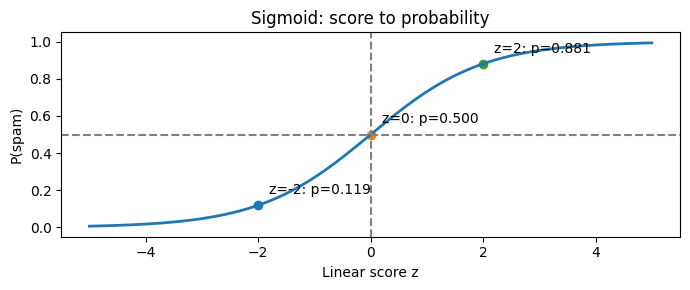

In [7]:
z = np.linspace(-5,5,300)
p = 1/(1+np.exp(-z))
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(z,p, lw=2); ax.axhline(.5, color='gray', ls='--'); ax.axvline(0,color='gray',ls='--')
for score in [-2,0,2]:
    prob = 1/(1+np.exp(-score))
    ax.scatter(score,prob); ax.annotate(f'z={score}: p={prob:.3f}',(score,prob),xytext=(8,8),textcoords='offset points')
ax.set(xlabel='Linear score z', ylabel='P(spam)', title='Sigmoid: score to probability', ylim=(-.05,1.05))
plt.tight_layout(); plt.show()


概率与几率不是同一个量：几率 $=p/(1-p)$。若 $p=0.8$，几率为 4。对真实正类，交叉熵为 $-\ln(p)$，因此把真实垃圾邮件判成 0.1 的损失远大于判成 0.9。


In [8]:
example_p = np.array([.9,.5,.1])
display(pd.DataFrame({'真实标签 y':[1]*3,'预测正类概率 p':example_p,
                      '几率 p/(1-p)':example_p/(1-example_p),
                      '交叉熵 -ln(p)':-np.log(example_p)}).round(3))


,真实标签 y,预测正类概率 p,几率 p/(1-p),交叉熵 -ln(p)
0,1,0.9,9.000,0.105
1,1,0.5,1.000,0.693
2,1,0.1,0.111,2.303


训练时同时考虑标准化、正则化和交叉验证。标准化与模型放在同一 `Pipeline`，每个交叉验证折内只从该折训练部分学习均值与标准差。`C` 越小通常正则越强。这里用 5 折平均 F1 选择 `C`，**测试集不参与选择**。


In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_rows = []
for C in [.1,1,10]:
    pipe = make_pipeline(StandardScaler(), LogisticRegression(C=C, solver='liblinear', max_iter=1000))
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')
    lr_rows.append({'C':C, '5折平均F1':scores.mean(), '折间标准差':scores.std()})
lr_cv = pd.DataFrame(lr_rows)
display(lr_cv.round(3))
best_C = lr_cv.loc[lr_cv['5折平均F1'].idxmax(),'C']
lr = make_pipeline(StandardScaler(), LogisticRegression(C=best_C, solver='liblinear', max_iter=1000))
lr.fit(X_train,y_train)
print('最终 C =',best_C)


,C,5折平均F1,折间标准差
0,0.1,0.892,0.007
1,1.0,0.893,0.012
2,10.0,0.895,0.014


最终 C = 10.0


线性系数的正负表示在其他**标准化后特征保持不变**时，某个特征增大如何改变对数几率。相关特征常共同变化，不能把系数简单解释为因果作用。


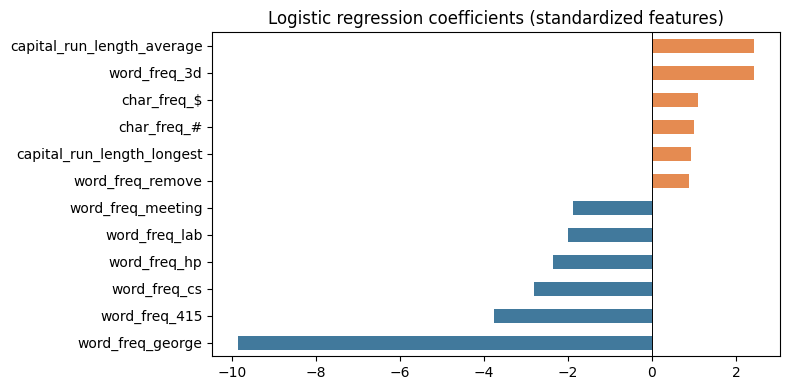

In [10]:
coefs = pd.Series(lr.named_steps['logisticregression'].coef_[0], index=X.columns).sort_values()
selected = pd.concat([coefs.head(6),coefs.tail(6)])
selected.plot.barh(figsize=(8,4),color=np.where(selected>0,'#e58b51','#41799c'))
plt.axvline(0,color='black',lw=.7); plt.title('Logistic regression coefficients (standardized features)')
plt.tight_layout(); plt.show()


在验证集上观察阈值：放宽阈值通常增加召回率，也可能增加正常邮件误报。数据来源说明特别指出，将正常邮件误拦成垃圾邮件是重要代价。这里用一个**演示用业务约束**：验证集查准率至少 95%，在满足条件的阈值中选择召回率最高者。95% 是本课堂的决策设定，不是数据集提供的真实业务成本。


,阈值,查准率,召回率,预测为垃圾的封数
20,0.5,0.927,0.904,327


验证集满足约束的阈值： 22 个；选择阈值： 0.74


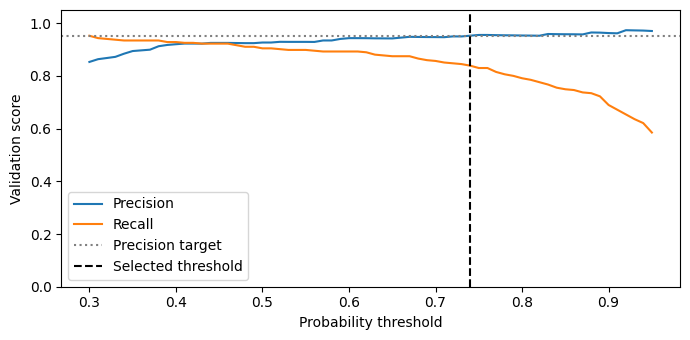

In [11]:
from sklearn.metrics import precision_score, recall_score

val_p = lr.predict_proba(X_val)[:,1]
thresholds = np.round(np.arange(.30,.951,.01),2)
threshold_results = pd.DataFrame([
    {'阈值':t, '查准率':precision_score(y_val,val_p>=t,zero_division=0),
     '召回率':recall_score(y_val,val_p>=t,zero_division=0),
     '预测为垃圾的封数':int((val_p>=t).sum())} for t in thresholds])
eligible = threshold_results[(threshold_results['查准率']>=.95) & (threshold_results['预测为垃圾的封数']>0)]
chosen_threshold = float(eligible.sort_values(['召回率','阈值'],ascending=[False,True]).iloc[0]['阈值']) if len(eligible) else .5
display(threshold_results.iloc[(threshold_results['阈值']-.5).abs().argsort()[:1]].round(3))
print('验证集满足约束的阈值：',len(eligible),'个；选择阈值：',chosen_threshold)
fig,ax=plt.subplots(figsize=(7,3.5))
ax.plot(threshold_results['阈值'],threshold_results['查准率'],label='Precision')
ax.plot(threshold_results['阈值'],threshold_results['召回率'],label='Recall')
ax.axhline(.95,color='gray',ls=':',label='Precision target')
ax.axvline(chosen_threshold,color='black',ls='--',label='Selected threshold')
ax.set(xlabel='Probability threshold',ylabel='Validation score',ylim=(0,1.05));ax.legend(loc='lower left')
plt.tight_layout();plt.show()


## 3. K 近邻：距离、投票、尺度与搜索

K 近邻保留训练样本。对新邮件先找最相近的 $k$ 封，再按邻居标签投票。以查询点 $(0,0)$ 的四个候选点为例；前三个欧氏距离依次是 $1,2,\sqrt5$，正类占两票。


,x,y,label,Euclidean dist
0,1,0,1,1.000
1,0,2,0,2.000
2,2,1,1,2.236
3,3,0,0,3.000


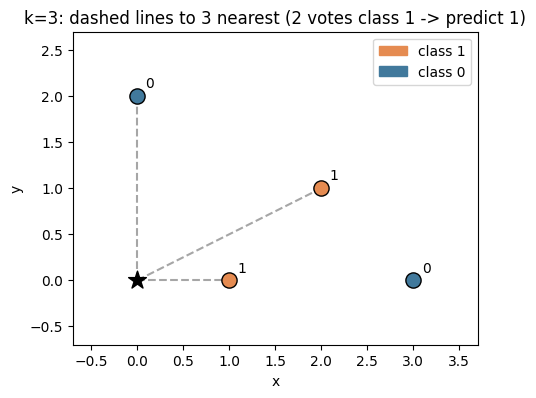

In [33]:
import matplotlib.patches as mpatches

train_points=np.array([[1,0],[0,2],[2,1],[3,0]])
train_labels=np.array([1,0,1,0])
query=np.array([0,0])
dist=np.linalg.norm(train_points-query,axis=1)
neighbors=pd.DataFrame({'x':train_points[:,0], 'y':train_points[:,1],
                        'label':train_labels,'Euclidean dist':dist}).sort_values('Euclidean dist')
display(neighbors.round(3))

fig,ax=plt.subplots(figsize=(5,4))
colors={1:'#e58b51',0:'#41799c'}
for (x,y),lab in zip(train_points,train_labels):
    ax.scatter(x,y,s=120,color=colors[lab],edgecolor='black',zorder=3)
    ax.annotate(f'{lab}',(x,y),xytext=(6,6),textcoords='offset points')
ax.scatter(*query,s=180,marker='*',color='black',zorder=4,label='query (0,0)')
for idx in neighbors.head(3).index:
    x,y=train_points[idx]
    ax.plot([query[0],x],[query[1],y],'--',color='gray',alpha=.7,lw=1.5,zorder=2)
ax.set(xlabel='x',ylabel='y',xlim=(-.7,3.7),ylim=(-.7,2.7),aspect='equal',
       title='k=3: dashed lines to 3 nearest (2 votes class 1 -> predict 1)')
ax.legend(handles=[mpatches.Patch(color=colors[1],label='class 1'),
                   mpatches.Patch(color=colors[0],label='class 0')],loc='upper right')
plt.tight_layout();plt.show()


比较多种距离。同样从 $(1,1)$ 到 $(4,5)$：欧氏距离 5，曼哈顿距离 7，切比雪夫距离 4。余弦相似度关注方向；对于零向量需要单独约定。


,distance,value
0,Euclidean L2,5.0
1,Manhattan L1,7.0
2,Chebyshev L_inf,4.0


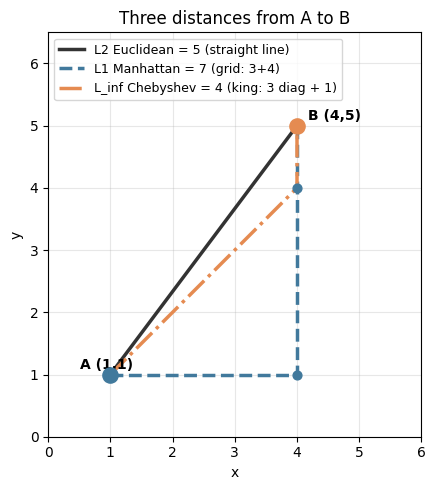

In [34]:
a=np.array([1,1]); b=np.array([4,5]); diff=np.abs(a-b)
display(pd.DataFrame({'distance':['Euclidean L2','Manhattan L1','Chebyshev L_inf'],
                      'value':[np.linalg.norm(diff,2),np.linalg.norm(diff,1),np.linalg.norm(diff,np.inf)]}))

fig,ax=plt.subplots(figsize=(6,5))
# A, B
ax.scatter(*a,s=120,color='#41799c',zorder=5); ax.annotate('A (1,1)',a,xytext=(-22,4),textcoords='offset points',fontweight='bold')
ax.scatter(*b,s=120,color='#e58b51',zorder=5); ax.annotate('B (4,5)',b,xytext=(8,4),textcoords='offset points',fontweight='bold')

# L2: straight line
ax.plot([a[0],b[0]],[a[1],b[1]],color='#333333',lw=2.5,ls='-',label='L2 Euclidean = 5 (straight line)')

# L1: right-then-up  A -> (4,1) -> B
ax.plot([a[0],b[0],b[0]],[a[1],a[1],b[1]],color='#41799c',lw=2.5,ls='--',label='L1 Manhattan = 7 (grid: 3+4)')

# L_inf: diagonal-then-up  A -> (4,4) -> B
ax.plot([a[0],b[0],b[0]],[a[1],b[1]-1,b[1]],color='#e58b51',lw=2.5,ls='-.',label='L_inf Chebyshev = 4 (king: 3 diag + 1)')

# corner markers
ax.scatter([4,4],[1,4],s=40,color='#41799c',zorder=4)
ax.set(xlim=(0,6),ylim=(0,6.5),aspect='equal',xlabel='x',ylabel='y',
       title='Three distances from A to B')
ax.legend(loc='upper left',fontsize=9); ax.grid(alpha=.3)
plt.tight_layout();plt.show()


实际邮件中，词频百分比和大写字母总数的取值范围差别很大。直接用欧氏距离时，大尺度特征容易主导邻居。下表对同一封验证邮件分别计算原始空间与标准化空间的五个邻居；标准化器只在训练集拟合。


,raw-space row,raw dist,std-space row,std dist
0,3397,2.04,3397,0.40
1,3249,2.06,1941,0.53
2,4211,2.13,1840,0.62
3,1908,2.38,323,0.84
4,2537,2.51,3432,0.84


overlap neighbors: 1 of 5


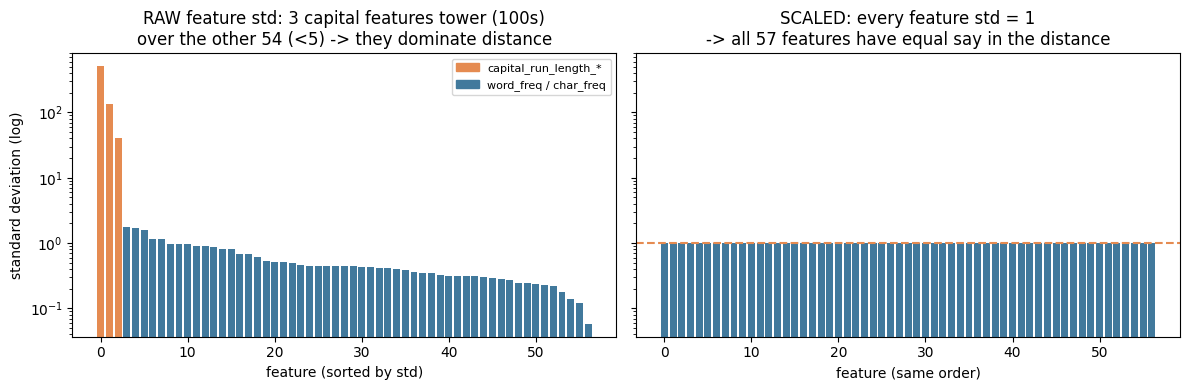

In [35]:
from sklearn.neighbors import NearestNeighbors

q=X_val.iloc[[0]]
scale=StandardScaler().fit(X_train)
raw_d, raw_i=NearestNeighbors(n_neighbors=5).fit(X_train).kneighbors(q)
std_d,std_i=NearestNeighbors(n_neighbors=5).fit(scale.transform(X_train)).kneighbors(scale.transform(q))
display(pd.DataFrame({'raw-space row':X_train.index[raw_i[0]],
                      'raw dist':raw_d[0], 'std-space row':X_train.index[std_i[0]],
                      'std dist':std_d[0]}).round(2))
print('overlap neighbors:',len(set(raw_i[0])&set(std_i[0])),'of 5')

# WHY the neighbors differ: feature scales
raw_std=X_train.std(ddof=0).sort_values(ascending=False)
cap_mask=raw_std.index.str.startswith('capital_run_length')
order=np.argsort(X_train.std(ddof=0).values)[::-1]   # same ordering for both panels
fig,axes=plt.subplots(1,2,figsize=(12,4),sharey=True)
# left: raw std (log y) — capital features tower
bar_colors=np.where(cap_mask,'#e58b51','#41799c')
axes[0].bar(range(len(raw_std)),raw_std.values,color=bar_colors)
axes[0].set(yscale='log',title='RAW feature std: 3 capital features tower (100s)\nover the other 54 (<5) -> they dominate distance',
            xlabel='feature (sorted by std)',ylabel='standard deviation (log)')
axes[0].legend(handles=[mpatches.Patch(color='#e58b51',label='capital_run_length_*'),
                        mpatches.Patch(color='#41799c',label='word_freq / char_freq')],loc='upper right',fontsize=8)
# right: after scaling, every feature std = 1
axes[1].bar(range(len(raw_std)),np.ones(len(raw_std)),color='#41799c')
axes[1].axhline(1,color='#e58b51',ls='--',lw=1.5)
axes[1].set(yscale='log',title='SCALED: every feature std = 1\n-> all 57 features have equal say in the distance',
            xlabel='feature (same order)')
plt.tight_layout();plt.show()


`k=1` 对局部噪声敏感；`k` 很大时少数类容易被大量邻居淹没。使用相同 5 折划分、相同评分规则比较候选 `k`，再用训练集拟合最佳配置。


,k,5-fold mean F1,5-fold std
0,1,0.843,0.013
1,5,0.848,0.020
2,15,0.832,0.027
3,35,0.806,0.036


best k = 5


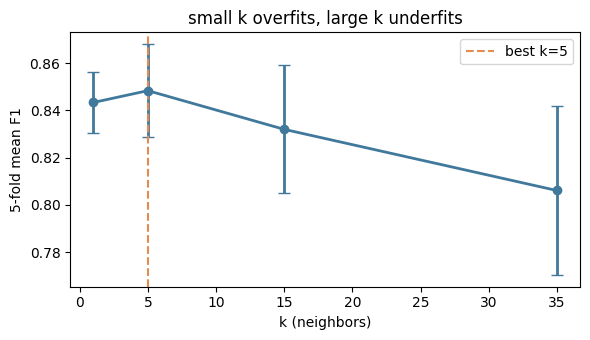

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn_rows=[]
for k in [1,5,15,35]:
    knn_pipe=make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=k,weights='uniform'))
    score=cross_val_score(knn_pipe,X_train,y_train,cv=cv,scoring='f1',n_jobs=1)
    knn_rows.append({'k':k,'5-fold mean F1':score.mean(),'5-fold std':score.std()})
knn_cv=pd.DataFrame(knn_rows)
display(knn_cv.round(3))
best_k=int(knn_cv.loc[knn_cv['5-fold mean F1'].idxmax(),'k'])
knn=make_pipeline(StandardScaler(),KNeighborsClassifier(n_neighbors=best_k))
knn.fit(X_train,y_train)
print('best k =',best_k)

fig,ax=plt.subplots(figsize=(6,3.5))
ax.errorbar(knn_cv['k'],knn_cv['5-fold mean F1'],yerr=knn_cv['5-fold std'],
            marker='o',lw=2,color='#41799c',capsize=4)
ax.axvline(best_k,color='#e58b51',ls='--',label=f'best k={best_k}')
ax.set(xlabel='k (neighbors)',ylabel='5-fold mean F1',title='small k overfits, large k underfits')
ax.legend();plt.tight_layout();plt.show()


等权投票和距离加权并非同一决策规则。在三位邻居的例子中，负类有两票，但最近的正类距离只有 0.2；以 $1/d$ 加权后正类权重为 5，负类权重之和约为 2.917。


,label,distance,1/d weight
0,pos,0.2,5.000
1,neg,0.6,1.667
2,neg,0.8,1.250


label
neg    2.917
pos    5.000
Name: 1/d weight, dtype: float64

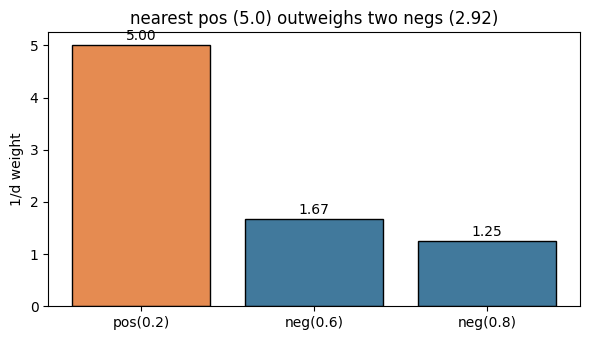

In [ ]:
weights_demo=pd.DataFrame({'label':['pos','neg','neg'],'distance':[.2,.6,.8]})
weights_demo['1/d weight']=1/weights_demo['distance']
display(weights_demo.round(3))
display(weights_demo.groupby('label')['1/d weight'].sum().round(3))

## 4. 贝叶斯分类：先验、平滑与不同数据表示

数据集比例会影响先验。一个独立数字例子：1,000 封邮件中 100 封为垃圾；垃圾邮件中 80% 含“优惠”，正常邮件中 10% 含“优惠”。观察到“优惠”后，垃圾邮件的比例是 $80/(80+90)=47.1\%$，**不是 80%**。


In [54]:
prior=.1
likelihood_spam=.8
likelihood_normal=.1
posterior=prior*likelihood_spam/(prior*likelihood_spam+(1-prior)*likelihood_normal)
print(f'P(垃圾 | 含优惠) = {posterior:.3%}')


P(垃圾 | 含优惠) = 47.059%


### 4.1 课件中的五句体育文本：多项式朴素贝叶斯

以下五句是课件中的体育文本示例，不是 UCI 邮件文本。先转成小写并按空格分词，保留单字符 `a`。多项式模型使用真正的词次数，并按每个类别的总词数加词表大小做拉普拉斯平滑。


In [42]:
from collections import Counter

sentences=['A great game','The election was over','Very clean match',
           'A clean but forgettable game','It was a close election']
labels=['Sports','Not Sports','Sports','Sports','Not Sports']
tokens=[s.lower().split() for s in sentences]
counts={c:Counter(w for row,lab in zip(tokens,labels) if lab==c for w in row)
        for c in ['Sports','Not Sports']}
vocab=sorted(set(w for row in tokens for w in row))
table=pd.DataFrame({c:pd.Series(counts[c],index=vocab).fillna(0).astype(int)
                    for c in ['Sports','Not Sports']})
display(pd.DataFrame({'文本':sentences,'类别':labels}))
display(table.T)
print('体育类词总数：',sum(counts['Sports'].values()),'；非体育类：',sum(counts['Not Sports'].values()),'；词表：',len(vocab))


,文本,类别
0,A great game,Sports
1,The election was over,Not Sports
2,Very clean match,Sports
3,A clean but forgettable game,Sports
4,It was a close election,Not Sports


,a,but,clean,close,election,forgettable,game,great,it,match,over,the,very,was
Sports,2,1,2,0,0,1,2,1,0,1,0,0,1,0
Not Sports,1,0,0,1,2,0,0,0,1,0,1,1,0,2


体育类词总数： 11 ；非体育类： 9 ；词表： 14


测试句 `a very close game`：体育类中 `close` 计数为 0，非体育类中 `very` 与 `game` 计数为 0。不平滑时两个类别的连乘都为 0。加一平滑后，体育类分母 $11+14=25$，非体育类分母 $9+14=23$。


In [43]:
test_words='a very close game'.split()
prob_rows=[]
for word in test_words:
    prob_rows.append({'词':word,
     'Sports (计数+1)/25':(counts['Sports'][word]+1)/25,
     'Not Sports (计数+1)/23':(counts['Not Sports'][word]+1)/23})
display(pd.DataFrame(prob_rows).round(4))
prior_s,prior_n=3/5,2/5
score_s=prior_s*np.prod([(counts['Sports'][w]+1)/25 for w in test_words])
score_n=prior_n*np.prod([(counts['Not Sports'][w]+1)/23 for w in test_words])
print(f'Sports 未归一化分数：{score_s:.8g}；Not Sports：{score_n:.8g}')
print(f'归一化后的 Sports 概率：{score_s/(score_s+score_n):.3%}')


,词,Sports (计数+1)/25,Not Sports (计数+1)/23
0,a,0.12,0.0870
1,very,0.08,0.0435
2,close,0.04,0.0870
3,game,0.12,0.0435


Sports 未归一化分数：2.7648e-05；Not Sports：5.7175325e-06
归一化后的 Sports 概率：82.864%


### 4.2 在真实邮件特征上使用对应的朴素贝叶斯模型

UCI 提供的词频是百分比，大写字母统计也是连续数值，所以不能把这些数直接说成“原文词次数”。**GaussianNB** 用各类各特征的高斯密度建模；**BernoulliNB** 先把特征转为是否大于 0 的标记。交叉验证在训练集内比较两种表示，验证与测试仍保持独立。


In [50]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.preprocessing import Binarizer

nb_candidates={'GaussianNB（连续特征）':GaussianNB(),
               'BernoulliNB（是否出现）':make_pipeline(Binarizer(threshold=0.0),BernoulliNB(alpha=1.0))}
nb_rows=[]
for name,estimator in nb_candidates.items():
    sc=cross_val_score(estimator,X_train,y_train,cv=cv,scoring='f1')
    nb_rows.append({'模型':name,'5折平均F1':sc.mean(),'折间标准差':sc.std()})
nb_cv=pd.DataFrame(nb_rows).sort_values('5折平均F1',ascending=False)
display(nb_cv.round(3))
nb_name=nb_cv.iloc[0]['模型']
nb=nb_candidates[nb_name].fit(X_train,y_train)
print('训练集内选定：',nb_name)


,模型,5折平均F1,折间标准差
1,BernoulliNB（是否出现）,0.853,0.024
0,GaussianNB（连续特征）,0.811,0.011


训练集内选定： BernoulliNB（是否出现）


特征相关时，朴素贝叶斯的条件独立假设可能重复计算证据。因此分类准确度和输出概率的可信度需要分开检查；原始数据中也存在个人邮件来源词（如 `george`），不能把它们视作普遍垃圾邮件规律。


## 5. 独立测试：误报、漏报与模型比较

模型、`C`、`k`、朴素贝叶斯特征表示均从训练集选择，逻辑回归阈值从验证集选择。现在只使用一次保留的测试集；“正常判成垃圾”是误报（FP），“垃圾判成正常”是漏报（FN）。三模型的默认分类规则是正类概率至少 0.5；KNN 的近邻票数只是模型给出的比例，不必然是经过校准的真实概率。


In [51]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score

predictions={
    '逻辑回归（选定阈值）':(lr.predict_proba(X_test)[:,1]>=chosen_threshold).astype(int),
    'K近邻（默认规则）':knn.predict(X_test),
    '朴素贝叶斯（默认规则）':nb.predict(X_test)
}
metric_rows=[]
for name,pred in predictions.items():
    tn,fp,fn,tp=confusion_matrix(y_test,pred,labels=[0,1]).ravel()
    metric_rows.append({'模型':name,'准确率':accuracy_score(y_test,pred),
                        '查准率':precision_score(y_test,pred,zero_division=0),
                        '召回率':recall_score(y_test,pred,zero_division=0),
                        'F1':f1_score(y_test,pred,zero_division=0),
                        '误报 FP':fp,'漏报 FN':fn})
metrics=pd.DataFrame(metric_rows).set_index('模型')
display(metrics.round(3))


,准确率,查准率,召回率,F1,误报 FP,漏报 FN
模型,,,,,,
逻辑回归（选定阈值）,0.891,0.935,0.779,0.850,18,74
K近邻（默认规则）,0.914,0.897,0.887,0.892,34,38
朴素贝叶斯（默认规则）,0.892,0.886,0.836,0.860,36,55


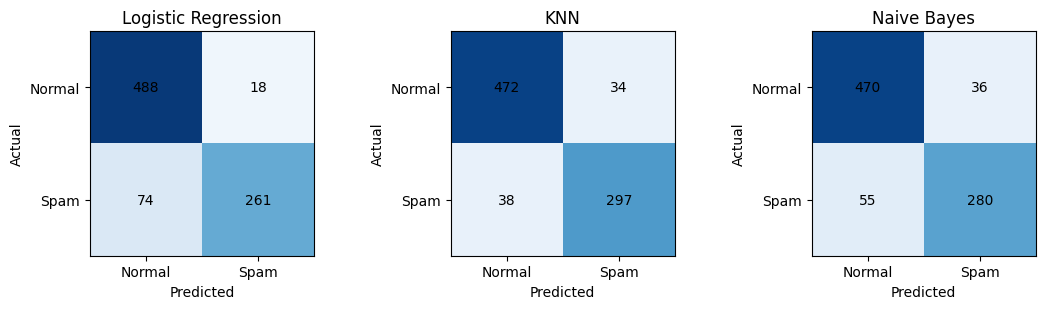

In [52]:
fig, axes=plt.subplots(1,3,figsize=(11,3.2))
title_en={'逻辑回归（选定阈值）':'Logistic Regression','K近邻（默认规则）':'KNN','朴素贝叶斯（默认规则）':'Naive Bayes'}
for ax,(name,pred) in zip(axes,predictions.items()):
    mat=confusion_matrix(y_test,pred,labels=[0,1])
    ax.imshow(mat,cmap='Blues',vmin=0,vmax=max(len(y_test[y_test==0]),len(y_test[y_test==1])))
    for (r,c),val in np.ndenumerate(mat):
        ax.text(c,r,str(val),ha='center',va='center',color='black')
    ax.set(xticks=[0,1],xticklabels=['Normal','Spam'],yticks=[0,1],yticklabels=['Normal','Spam'],
           xlabel='Predicted',ylabel='Actual',title=title_en[name])
plt.tight_layout();plt.show()


下面查看一封**真实测试记录的特征**，同时保留真实标签和三种模型的判断。数据源没有原始邮件正文，因此不能展示该邮件原文，也不能从这些 57 个已提取数值反推出整封邮件。


In [55]:
lr_pred=predictions['逻辑回归（选定阈值）']
wrong=np.flatnonzero(lr_pred!=y_test.to_numpy())
position=int(wrong[0]) if len(wrong) else 0
row=X_test.iloc[position]
print('测试集位置：',position,'；原数据行号：',X_test.index[position])
print('真实类别：', '垃圾' if y_test.iloc[position] else '正常')
print('逻辑回归预测概率：{:.3f}；课堂选定阈值：{:.2f}'.format(lr.predict_proba(X_test.iloc[[position]])[0,1],chosen_threshold))
for name,pred in predictions.items(): print(name,'→','垃圾' if pred[position] else '正常')
display(row[['word_freq_free','word_freq_money','word_freq_george','char_freq_!',
             'capital_run_length_average','capital_run_length_total']].to_frame('原始记录中的值'))


测试集位置： 2 ；原数据行号： 2615
真实类别： 正常
逻辑回归预测概率：0.925；课堂选定阈值：0.74
逻辑回归（选定阈值） → 垃圾
K近邻（默认规则） → 垃圾
朴素贝叶斯（默认规则） → 垃圾


,原始记录中的值
word_freq_free,0.840
word_freq_money,0.000
word_freq_george,0.000
char_freq_!,0.374
capital_run_length_average,2.892
capital_run_length_total,405.000


### 小结

| 模型 | 主要机制 | 本实验中与之对应的数据表示 |
|:--|:--|:--|
| 逻辑回归 | $w^Tx+b$ 经 Sigmoid 得到概率；阈值负责最终行动 | 标准化的 57 项邮件特征 |
| K 近邻 | 距离选邻居，再投票 | 同一训练集内拟合的标准化特征 |
| 多项式朴素贝叶斯 | 真正的词次数、先验、平滑 | 课件的五句体育文本手算 |
| 高斯 / 伯努利朴素贝叶斯 | 连续数值密度 / 是否出现的标记 | Spambase 的数值特征 / 二值特征 |

真实邮件分类的结论只对应这份历史数据与本次划分。对新来源邮件、不同语言、时间变化以及代价不对称的部署，需要重新收集数据与验证。
